# Literature

<img src="https://www.researchgate.net/publication/301316394/figure/fig1/AS:11431281252986839@1718821248214/a-A-schematic-diagram-of-2D-Kagome-lattice-structure-with-each-unit-cell-consisting-of.jpg" alt="Kagome Bulk" width="800">

# Model

In [ ]:
from topological_insulator import Problem

structure_path = "../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name)

In [ ]:
subs = ["A", "B", "C"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    for nn_label in subs:
        if sub_label == nn_label:
            continue
        parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1

In [3]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 500, # reciprocal space discretization
    location = location,
    BZ = "reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


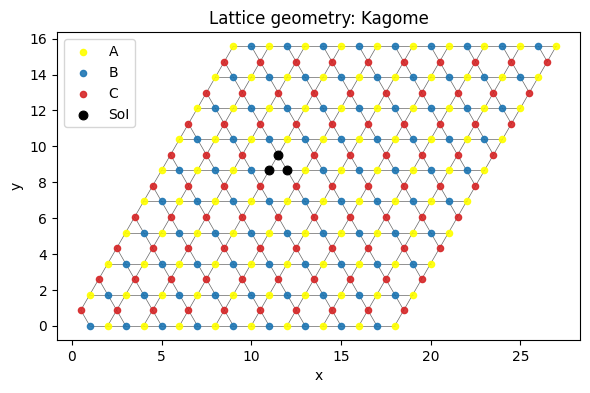

In [4]:
tb = problem.hamiltonian[location]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [5]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


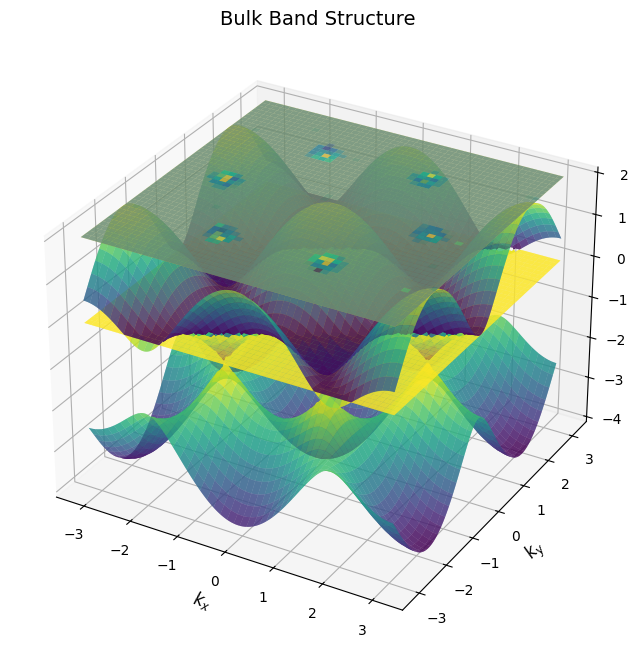

In [6]:
problem.plot(plot_type="dispersion", location=location)

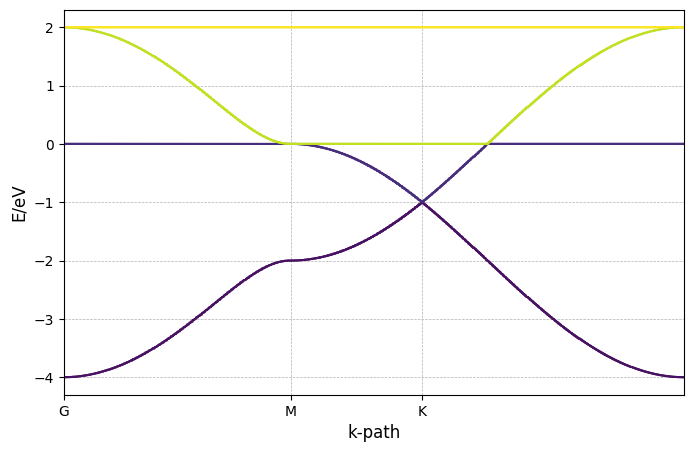

In [7]:
problem.plot(plot_type="high_symmetry", location=location)